# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook presuppone questi moduli nello stesso progetto:

- `sudoku_solver.py`
- `sudoku_archive.py`
- `sudoku_visualization.py`


In [ ]:
import random
import time
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

plt.rcParams["figure.figsize"] = (7, 7)
i = 0


In [ ]:
sudoku_ref_list = sa.list_sudokus()
sudoku_list = [sa.load_sudoku(x['name']) for x in sudoku_ref_list]
sudoku_analysis_list = [sa.analyse_puzzle_cached(x['grid'], x['name']) for x in sudoku_list]

KeyboardInterrupt: 

## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


Sudoku caricato
ID: 17b4499829b4dd76c23c
Nome: coach_mh_21
Percorso: sudoku_data\puzzles\17b4499829b4dd76c23c.json


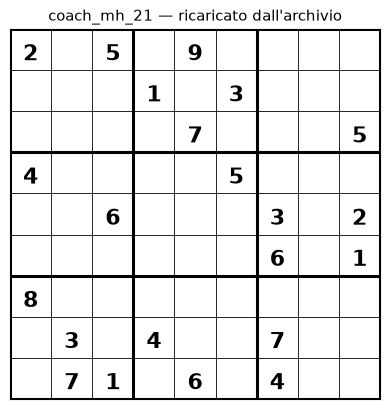

In [ ]:
#loaded_info = sa.load_sudoku('coach_dev_1')
loaded_info = sudoku_list[i]
loaded_puzzle = loaded_info["grid"]
first_result = sudoku_analysis_list[i]

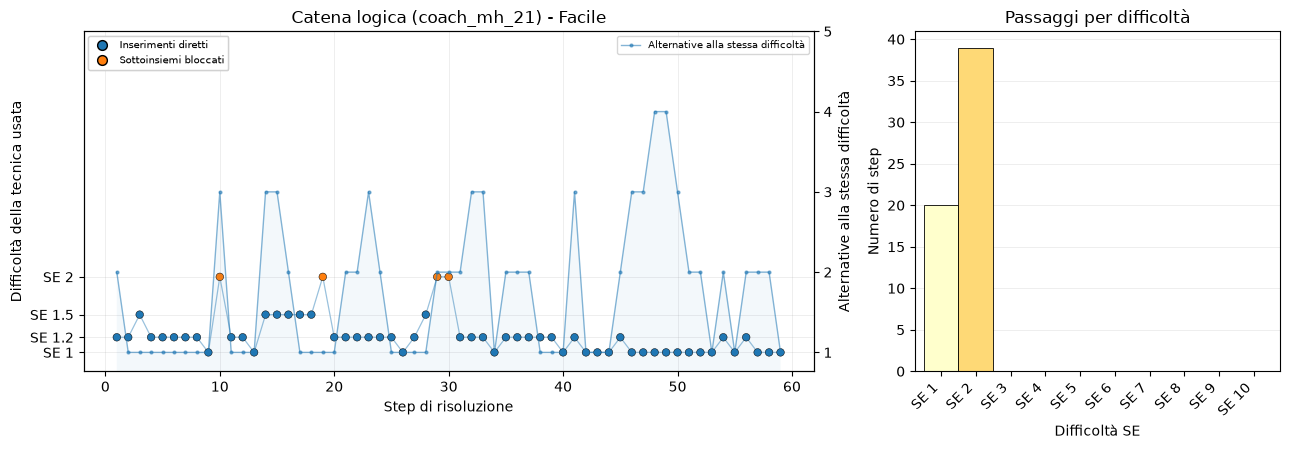

In [ ]:
sv.plot_difficulty_chain(first_result)

In [ ]:
print("Sudoku caricato")
print("ID:", loaded_info["id"])
print("Nome:", loaded_info["name"])
print("Percorso:", loaded_info["path"])

sv.draw_grid(
    loaded_puzzle,
    title=f"{loaded_info['name']} — ricaricato dall'archivio",
)
plt.show()


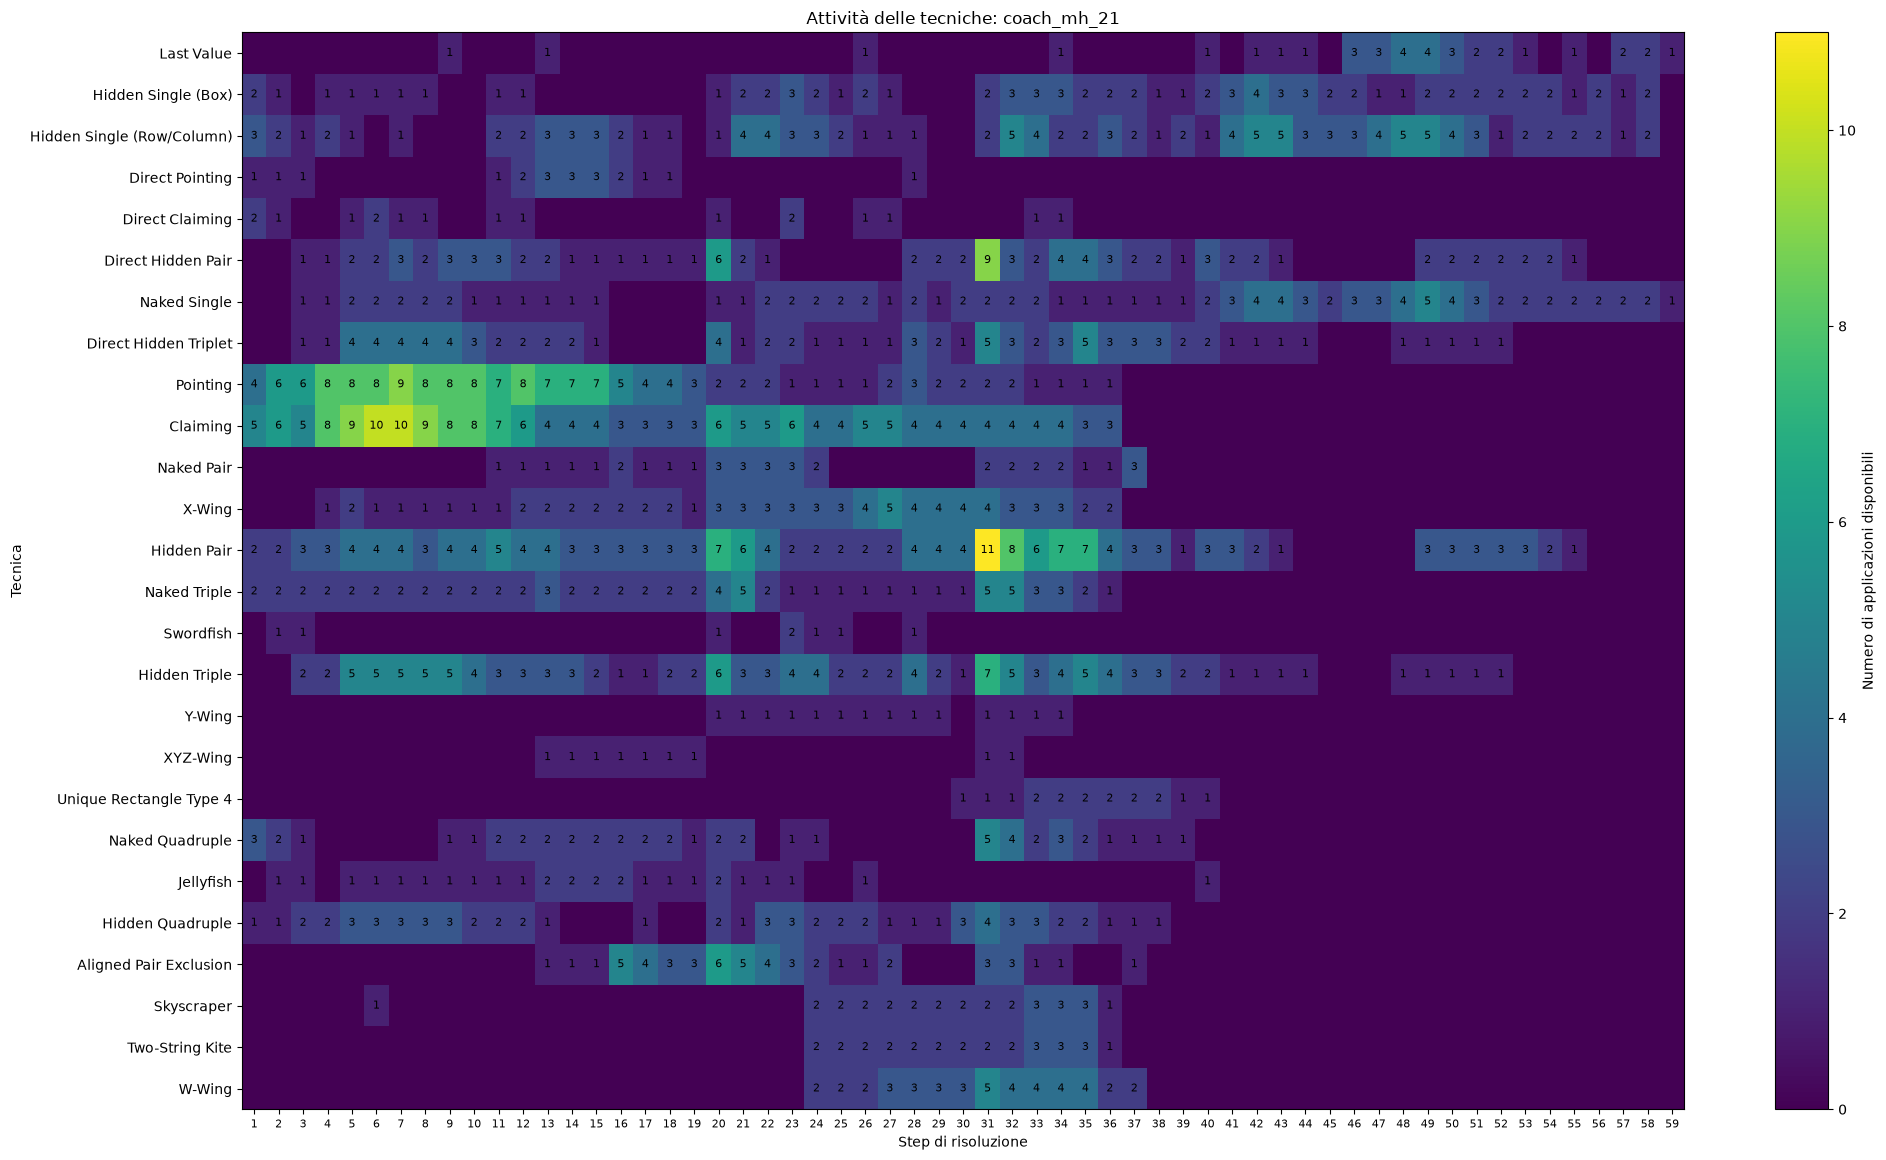

In [ ]:
if hasattr(sv, "plot_technique_activity"):
    has_activity_data = any(
        "applicable_by_technique" in step
        for step in first_result["chain"]
    )

    if has_activity_data:
        sv.plot_technique_activity(first_result)
    else:
        print(
            "La funzione esiste, ma l'analisi non contiene "
            "'applicable_by_technique'. Aggiorna solve_and_log "
            "e incrementa ANALYSIS_VERSION."
        )
else:
    print(
        "plot_technique_activity non è presente in "
        "sudoku_visualization.py."
    )
